# Road Condition Classification using ResNet
This notebook implements a ResNet-based image classification model to classify road conditions into 15 categories using the Viscoda RoadSaW dataset. Evaluation metrics such as precision, recall, F1-score, ROC-AUC, and confusion matrix are included.

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

## 1. Device Configuration
Check for GPU availability and set up the device configuration.

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Using device: {device}')

Using device: cuda


## 2. Data Directories
Set up paths to the dataset directories.

In [21]:
data_dir = "C:/Users/shres/Documents/dataset/RoadSaW-150_l"
train_dir = os.path.join(data_dir, 'train')
val_dir = os.path.join(data_dir, 'validation')
test_dir = os.path.join(data_dir, 'test')

## 3. Data Transformations
Define transformations to preprocess the images for input into the ResNet model.

In [22]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

## 4. Load Datasets and DataLoaders
Load the train, validation, and test datasets.

In [23]:
train_dataset = datasets.ImageFolder(train_dir, transform=transform)
val_dataset = datasets.ImageFolder(val_dir, transform=transform)
test_dataset = datasets.ImageFolder(test_dir, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

class_names = train_dataset.classes
print(f'Classes: {class_names}')

Classes: ['asphalt_damp', 'asphalt_dry', 'asphalt_verywet', 'asphalt_wet', 'cobble_damp', 'cobble_dry', 'cobble_verywet', 'cobble_wet', 'concrete_damp', 'concrete_dry', 'concrete_verywet', 'concrete_wet', 'fresh_snow', 'fully_packed', 'partially_covered']


## 5. Define the ResNet Model
Modify the ResNet model for classification into 15 categories.

In [24]:

# Load the pretrained ResNet50 model using the weights argument
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)  # Or use DEFAULT to get the latest weights

# Update the fully connected layer to match the number of classes
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, len(class_names))

# Move the model to the appropriate device
model = model.to(device)

## 6. Loss Function and Optimizer
Set up the loss function and optimizer.

In [25]:
criterion = nn.CrossEntropyLoss()
#optimizer = optim.Adam(model.parameters(), lr=0.001)
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)

## 7. Train the Model
Train the ResNet model and display loss and accuracy for each epoch.

In [26]:
from sklearn.metrics import precision_recall_fscore_support

num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Statistics
        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        # Collect all predictions and labels for calculating precision, recall, and F1-score
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = correct / total

    # Calculate precision, recall, and F1-score
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted')

    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}, '
          f'Precision: {precision:.4f}, Recall: {recall:.4f}, F1-Score: {f1:.4f}')

    # Validation phase
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    val_preds = []
    val_labels = []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

            # Collect all predictions and labels for calculating precision, recall, and F1-score
            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    val_loss /= len(val_dataset)
    val_acc = val_correct / val_total

    # Calculate precision, recall, and F1-score for validation
    val_precision, val_recall, val_f1, _ = precision_recall_fscore_support(val_labels, val_preds, average='weighted')

    print(f'Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_acc:.4f}, '
          f'Validation Precision: {val_precision:.4f}, Validation Recall: {val_recall:.4f}, '
          f'Validation F1-Score: {val_f1:.4f}')


Epoch 1/10, Loss: 0.8606, Accuracy: 0.6801, Precision: 0.6802, Recall: 0.6801, F1-Score: 0.6797
Validation Loss: 0.9667, Validation Accuracy: 0.6594, Validation Precision: 0.6945, Validation Recall: 0.6594, Validation F1-Score: 0.6380
Epoch 2/10, Loss: 0.5471, Accuracy: 0.7792, Precision: 0.7799, Recall: 0.7792, F1-Score: 0.7790
Validation Loss: 0.8241, Validation Accuracy: 0.7044, Validation Precision: 0.7041, Validation Recall: 0.7044, Validation F1-Score: 0.6978
Epoch 3/10, Loss: 0.4684, Accuracy: 0.8110, Precision: 0.8119, Recall: 0.8110, F1-Score: 0.8107
Validation Loss: 0.8111, Validation Accuracy: 0.7441, Validation Precision: 0.7434, Validation Recall: 0.7441, Validation F1-Score: 0.7266
Epoch 4/10, Loss: 0.3510, Accuracy: 0.8498, Precision: 0.8506, Recall: 0.8498, F1-Score: 0.8496
Validation Loss: 0.7569, Validation Accuracy: 0.7542, Validation Precision: 0.7703, Validation Recall: 0.7542, Validation F1-Score: 0.7432
Epoch 5/10, Loss: 0.3377, Accuracy: 0.8629, Precision: 0.863

## 8. Evaluate the Model
Define a function to evaluate the model using metrics like precision, recall, F1-score, ROC-AUC, and confusion matrix.

In [27]:
def evaluate_model(model, dataloader, class_names):
    model.eval()
    y_true = []
    y_pred = []
    y_proba = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_proba.extend(torch.nn.functional.softmax(outputs, dim=1).cpu().numpy())

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    roc_auc = roc_auc_score(y_true, y_proba, multi_class='ovr', average='weighted')
    conf_matrix = confusion_matrix(y_true, y_pred)

    print(f'Accuracy: {accuracy:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall: {recall:.4f}')
    print(f'F1-Score: {f1:.4f}')
    print(f'ROC-AUC: {roc_auc:.4f}')

    plt.figure(figsize=(10, 7))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

    print('\nClassification Report:')
    print(classification_report(y_true, y_pred, target_names=class_names))

## 9. Test the Model
Use the test dataset to evaluate the model's performance.

Accuracy: 0.7368
Precision: 0.7564
Recall: 0.7368
F1-Score: 0.7246
ROC-AUC: 0.9860


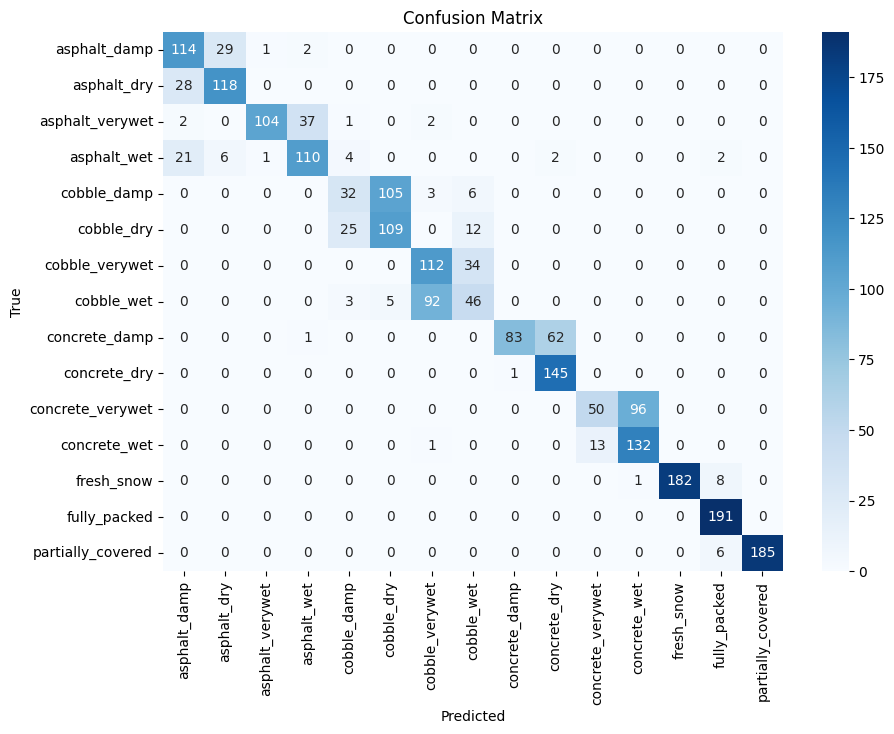


Classification Report:
                   precision    recall  f1-score   support

     asphalt_damp       0.69      0.78      0.73       146
      asphalt_dry       0.77      0.81      0.79       146
  asphalt_verywet       0.98      0.71      0.83       146
      asphalt_wet       0.73      0.75      0.74       146
      cobble_damp       0.49      0.22      0.30       146
       cobble_dry       0.50      0.75      0.60       146
   cobble_verywet       0.53      0.77      0.63       146
       cobble_wet       0.47      0.32      0.38       146
    concrete_damp       0.99      0.57      0.72       146
     concrete_dry       0.69      0.99      0.82       146
 concrete_verywet       0.79      0.34      0.48       146
     concrete_wet       0.58      0.90      0.70       146
       fresh_snow       1.00      0.95      0.98       191
     fully_packed       0.92      1.00      0.96       191
partially_covered       1.00      0.97      0.98       191

         accuracy             

In [28]:
evaluate_model(model, test_loader, class_names)